# Task 5: Time Series Forecasting

Forecasting Cairo daily mean temperature using ARIMA, SARIMAX, and LSTM.

In [1]:
!pip install pmdarima tensorflow --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

metrics = {}  # store results for final comparison

## 1. Data Loading & Exploration

In [3]:
df = pd.read_csv('cairo_weather_clean.csv', parse_dates=['date'], index_col='date')
df = df.asfreq('D')

print(df.shape)
df.describe()

(730, 7)


,temp_mean,temp_max,temp_min,precipitation,humidity,wind_speed,cloud_cover
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,22.167397,29.956260,15.421767,0.425137,53.450260,2.833411,26.828699
std,7.119663,7.864466,6.129371,2.272672,13.551634,0.848146,22.327618
min,6.670000,11.790000,1.140000,0.000000,21.280000,0.750000,0.280000
25%,16.147500,23.015000,10.342500,0.000000,43.937500,2.260000,9.957500
50%,22.935000,30.735000,15.945000,0.000000,51.745000,2.830000,20.250000
75%,29.027500,37.305000,21.080000,0.020000,63.822500,3.370000,39.580000
max,35.050000,44.300000,27.510000,34.090000,84.600000,5.700000,99.340000


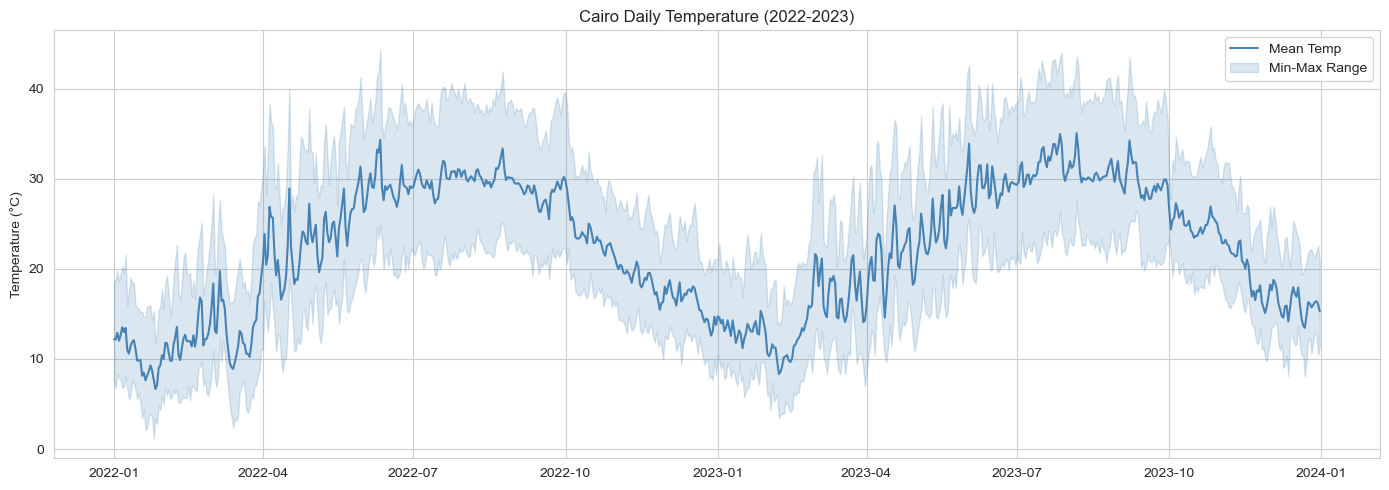

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['temp_mean'], label='Mean Temp', color='steelblue')
ax.fill_between(df.index, df['temp_min'], df['temp_max'], alpha=0.2, color='steelblue', label='Min-Max Range')
ax.set_title('Cairo Daily Temperature (2022-2023)')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

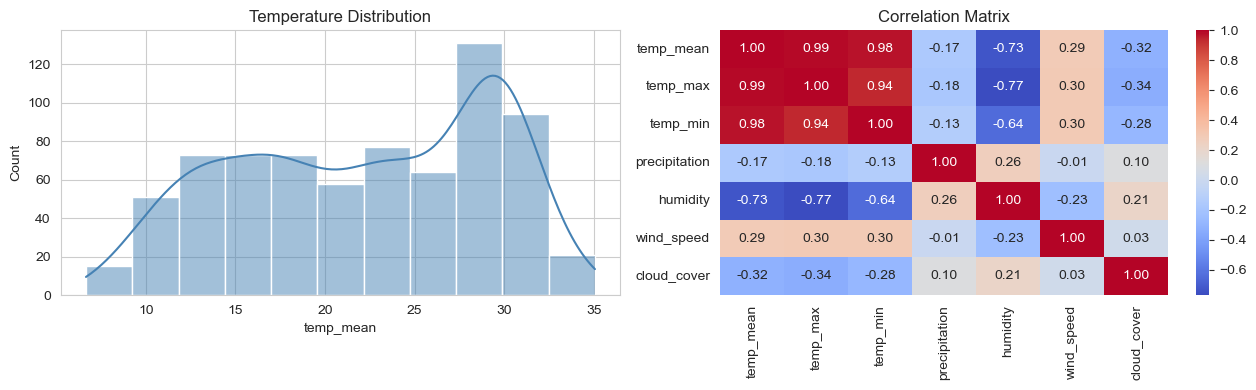

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['temp_mean'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Temperature Distribution')

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 2. Preprocessing

In [6]:
# check for gaps
print("Missing values:")
print(df.isnull().sum())

# interpolate any gaps
df.interpolate(method='time', limit_direction='both', inplace=True)

# rolling z-score outlier detection (window=30)
roll_mean = df['temp_mean'].rolling(30, center=True).mean().bfill().ffill()
roll_std = df['temp_mean'].rolling(30, center=True).std().bfill().ffill()
z = (df['temp_mean'] - roll_mean) / roll_std
outliers = z.abs() > 3
print(f"\nOutliers found: {outliers.sum()}")

# cap outliers
df['temp_mean'] = df['temp_mean'].clip(lower=roll_mean - 3*roll_std, upper=roll_mean + 3*roll_std)

Missing values:
temp_mean        0
temp_max         0
temp_min         0
precipitation    0
humidity         0
wind_speed       0
cloud_cover      0
dtype: int64

Outliers found: 0


In [7]:
# feature engineering
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['lag_1'] = df['temp_mean'].shift(1)
df['lag_7'] = df['temp_mean'].shift(7)
df['roll_mean_7'] = df['temp_mean'].rolling(7).mean()
df['roll_mean_30'] = df['temp_mean'].rolling(30).mean()
df.bfill(inplace=True)

df.head()

,temp_mean,temp_max,temp_min,precipitation,humidity,wind_speed,cloud_cover,month,day_of_week,day_of_year,month_sin,month_cos,lag_1,lag_7,roll_mean_7,roll_mean_30
date,,,,,,,,,,,,,,,,
2022-01-01,12.20,18.29,7.63,0.51,76.69,1.46,29.74,1,5,1,0.5,0.866025,12.20,12.2,12.641429,10.294667
2022-01-02,12.18,18.83,6.79,0.33,80.83,1.77,40.34,1,6,2,0.5,0.866025,12.20,12.2,12.641429,10.294667
2022-01-03,12.91,19.76,8.35,0.40,79.94,1.79,18.90,1,0,3,0.5,0.866025,12.18,12.2,12.641429,10.294667
2022-01-04,12.02,18.59,7.90,0.15,75.24,1.73,20.97,1,1,4,0.5,0.866025,12.91,12.2,12.641429,10.294667
2022-01-05,12.67,19.56,7.71,0.00,62.56,0.94,3.95,1,2,5,0.5,0.866025,12.02,12.2,12.641429,10.294667


## 3. Train/Test Split\nChronological split — never shuffle time series data.

Train: 670 days | Test: 60 days


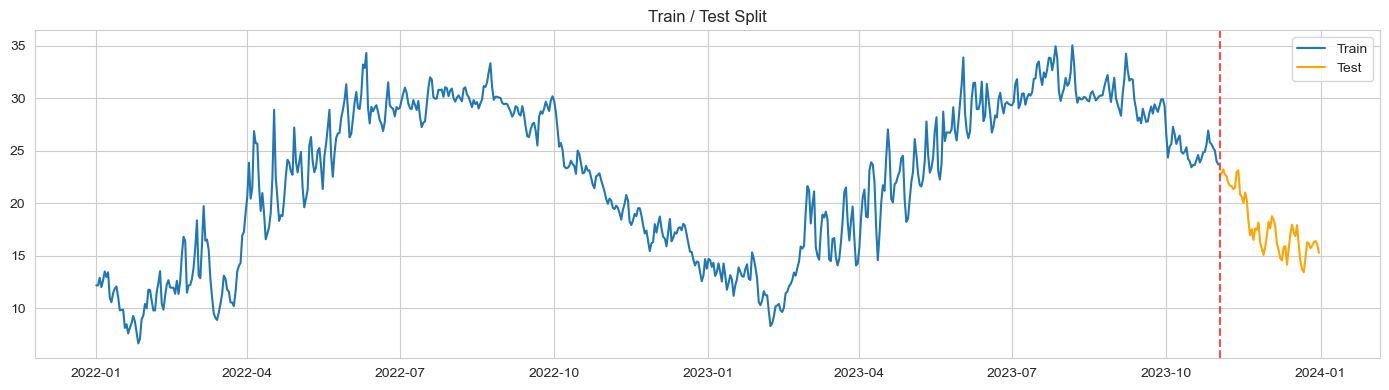

In [8]:
split = 60  # last 60 days as test
train = df.iloc[:-split]
test = df.iloc[-split:]

print(f"Train: {len(train)} days | Test: {len(test)} days")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['temp_mean'], label='Train')
ax.plot(test.index, test['temp_mean'], label='Test', color='orange')
ax.axvline(test.index[0], color='red', ls='--', alpha=0.7)
ax.legend()
ax.set_title('Train / Test Split')
plt.tight_layout()
plt.show()

## 4. Stationarity Tests\nARIMA requires a stationary series. We use ADF and KPSS.

In [9]:
def stationarity_test(series, name=''):
    adf_stat, adf_p, *_ = adfuller(series.dropna())
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"{name}")
    print(f"  ADF:  stat={adf_stat:.4f}, p={adf_p:.4f}  -> {'Stationary' if adf_p < 0.05 else 'Non-stationary'}")
    print(f"  KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f}  -> {'Stationary' if kpss_p >= 0.05 else 'Non-stationary'}")
    print()

stationarity_test(train['temp_mean'], 'Original series')

Original series
  ADF:  stat=-1.7677, p=0.3966  -> Non-stationary
  KPSS: stat=0.7945, p=0.0100  -> Non-stationary



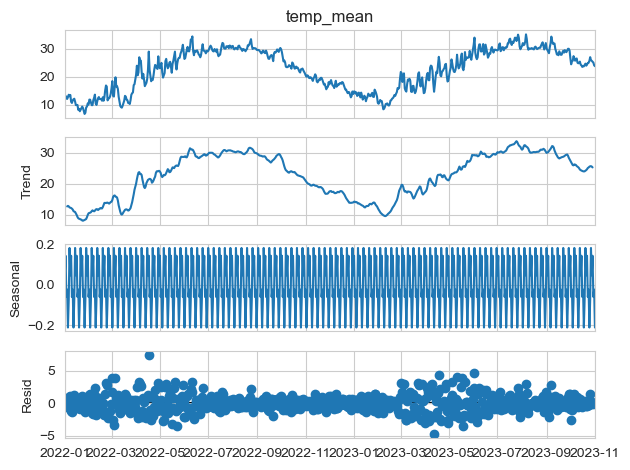

In [10]:
# seasonal decomposition
decomp = seasonal_decompose(train['temp_mean'], model='additive', period=7)
decomp.plot()
plt.tight_layout()
plt.show()

After first differencing
  ADF:  stat=-8.6657, p=0.0000  -> Stationary
  KPSS: stat=0.1251, p=0.1000  -> Stationary



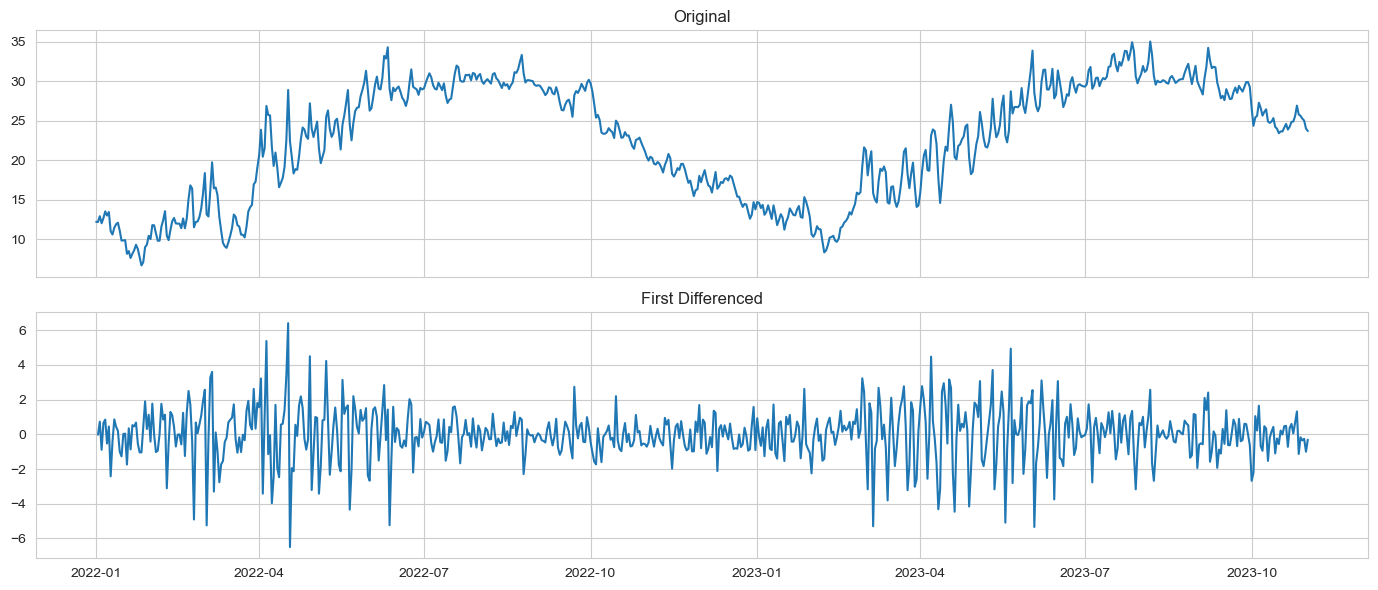

In [11]:
# first differencing
train_diff = train['temp_mean'].diff().dropna()
stationarity_test(train_diff, 'After first differencing')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['temp_mean'])
axes[0].set_title('Original')
axes[1].plot(train_diff)
axes[1].set_title('First Differenced')
plt.tight_layout()
plt.show()

## 5. ACF / PACF\nHelps estimate AR(p) and MA(q) orders.

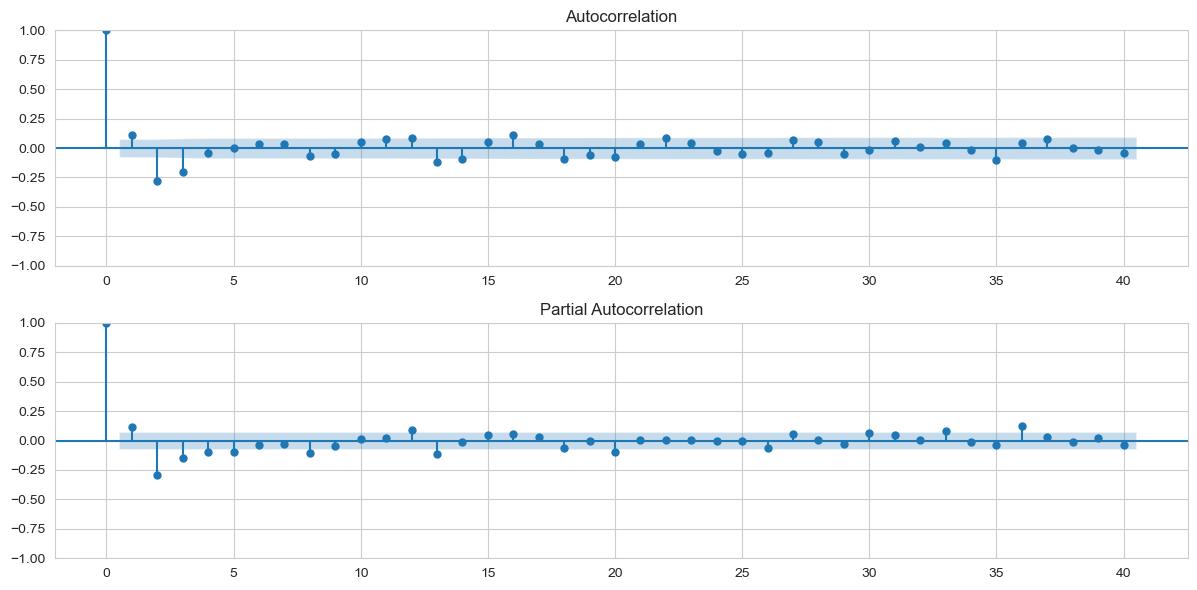

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(train_diff, lags=40, ax=axes[0])
plot_pacf(train_diff, lags=40, ax=axes[1], method='ywm')
plt.tight_layout()
plt.show()

## 6. ARIMA (Baseline)\nNon-seasonal baseline model.

In [13]:
# auto search for best (p,d,q)
auto_arima_model = pm.auto_arima(
    train['temp_mean'], seasonal=False,
    stepwise=True, trace=True, suppress_warnings=True
)
print(auto_arima_model.summary())
arima_order = auto_arima_model.order

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2336.632, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2428.027, Time=0.01 sec


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2421.606, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2413.325, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2426.117, Time=0.02 sec


 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2340.873, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2335.643, Time=0.18 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2405.258, Time=0.12 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2363.881, Time=0.06 sec


 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2336.569, Time=0.26 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2350.943, Time=0.09 sec


 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2338.569, Time=0.39 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=2334.046, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2403.330, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=2362.015, Time=0.04 sec


 ARIMA(3,1,1)(0,0,0)[0]             : AIC=2335.011, Time=0.13 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=2335.067, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=2419.677, Time=0.02 sec


 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2339.382, Time=0.19 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=2349.130, Time=0.06 sec


 ARIMA(3,1,2)(0,0,0)[0]             : AIC=2337.011, Time=0.19 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0]          
Total fit time: 2.556 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  670
Model:               SARIMAX(2, 1, 1)   Log Likelihood               -1163.023
Date:                Thu, 06 Aug 2026   AIC                           2334.046
Time:                        19:51:46   BIC                           2352.069
Sample:                    01-01-2022   HQIC                          2341.028
                         - 11-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7278      0.046     15.774      0.000       0.637 

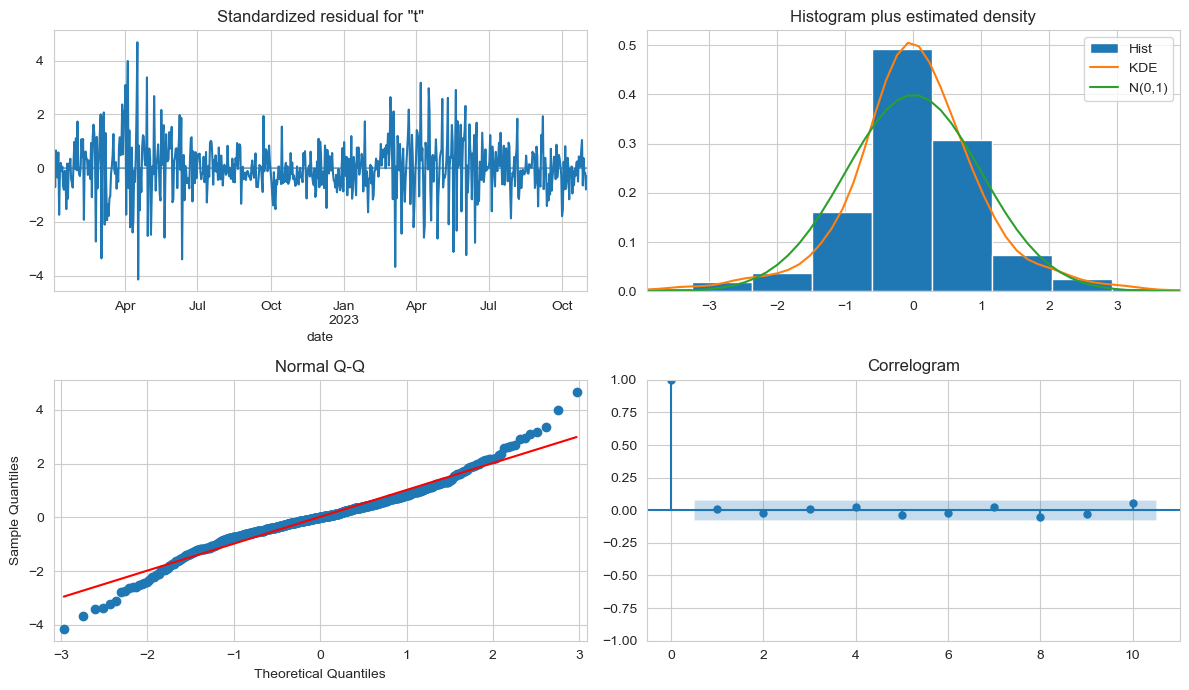

In [14]:
# fit and diagnostics
arima_fit = ARIMA(train['temp_mean'], order=arima_order).fit()
arima_fit.plot_diagnostics(figsize=(12, 7))
plt.tight_layout()
plt.show()

ARIMA  ->  MAE: 6.59, RMSE: 7.14, MAPE: 39.9%


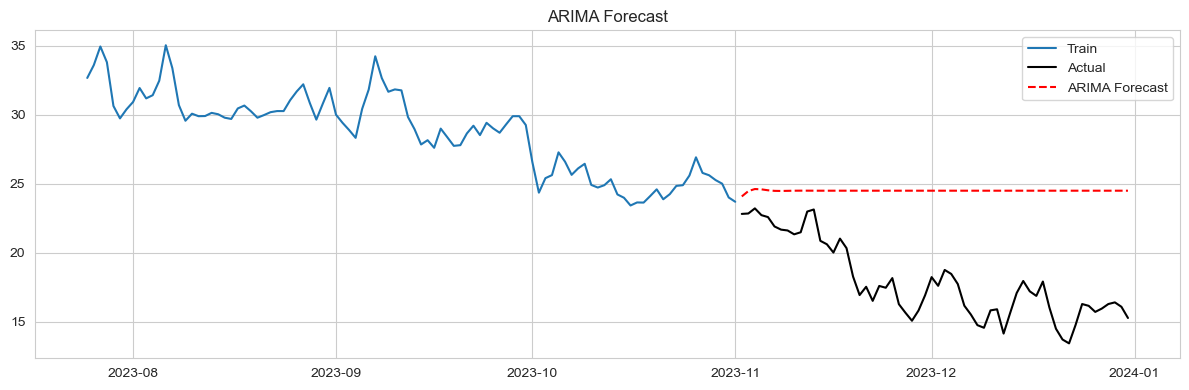

In [15]:
# forecast
arima_pred = arima_fit.forecast(steps=len(test))

mae = mean_absolute_error(test['temp_mean'], arima_pred)
rmse = np.sqrt(mean_squared_error(test['temp_mean'], arima_pred))
mape = np.mean(np.abs((test['temp_mean'] - arima_pred) / test['temp_mean'])) * 100

metrics['ARIMA'] = {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,1)}
print(f"ARIMA  ->  MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.1f}%")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index[-100:], train['temp_mean'].iloc[-100:], label='Train')
ax.plot(test.index, test['temp_mean'], label='Actual', color='black')
ax.plot(test.index, arima_pred, label='ARIMA Forecast', color='red', ls='--')
ax.legend()
ax.set_title('ARIMA Forecast')
plt.tight_layout()
plt.show()

## 7. SARIMAX with Fourier Terms

Plain SARIMA can\'t handle annual seasonality well (m=365 is too large). Instead we use **Fourier features** (sin/cos of day-of-year) as exogenous variables to capture the yearly cycle.

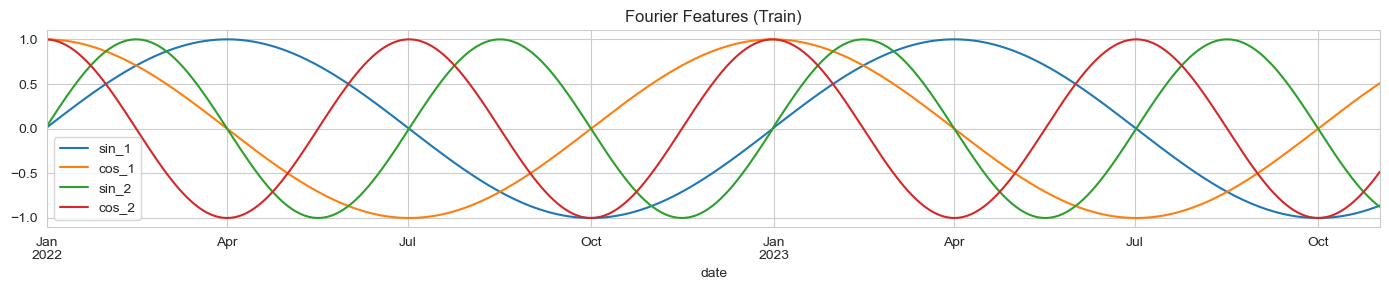

In [16]:
# Fourier features for annual seasonality
def make_fourier(index, period=365.25, K=2):
    doy = index.dayofyear
    cols = {}
    for k in range(1, K+1):
        cols[f'sin_{k}'] = np.sin(2 * np.pi * k * doy / period)
        cols[f'cos_{k}'] = np.cos(2 * np.pi * k * doy / period)
    return pd.DataFrame(cols, index=index)

fourier_train = make_fourier(train.index)
fourier_test = make_fourier(test.index)

fourier_train.plot(figsize=(14,3), title='Fourier Features (Train)')
plt.tight_layout()
plt.show()

In [17]:
# auto_arima with Fourier exog
auto_sarimax = pm.auto_arima(
    train['temp_mean'], X=fourier_train,
    seasonal=False, stepwise=True, trace=True, suppress_warnings=True
)
print(auto_sarimax.summary())
sarimax_order = auto_sarimax.order

Performing stepwise search to minimize aic


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.92 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2432.355, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2426.660, Time=0.10 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2418.735, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2430.361, Time=0.15 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2410.321, Time=0.26 sec


 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.78 sec


...

 ARIMA(1,1,5)(0,0,0)[0] intercept   : AIC=2303.342, Time=1.37 sec


 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=inf, Time=1.27 sec


 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.14 sec


 ARIMA(2,1,5)(0,0,0)[0] intercept   : AIC=2318.952, Time=1.47 sec


 ARIMA(1,1,4)(0,0,0)[0]             : AIC=inf, Time=0.85 sec

Best model:  ARIMA(1,1,4)(0,0,0)[0] intercept
Total fit time: 14.563 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  670
Model:               SARIMAX(1, 1, 4)   Log Likelihood               -1137.975
Date:                Thu, 06 Aug 2026   AIC                           2297.950
Time:                        19:52:02   BIC                           2347.514
Sample:                    01-01-2022   HQIC                          2317.149
                         - 11-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0007      0.001      0.817      0.414      -0.001     

In [18]:
# fit SARIMAX
sarimax_model = SARIMAX(
    train['temp_mean'], exog=fourier_train,
    order=sarimax_order,
    enforce_stationarity=False, enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              temp_mean   No. Observations:                  670
Model:               SARIMAX(1, 1, 4)   Log Likelihood               -1131.783
Date:                Thu, 06 Aug 2026   AIC                           2283.567
Time:                        19:52:03   BIC                           2328.549
Sample:                    01-01-2022   HQIC                          2300.997
                         - 11-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         -4.2152      0.460     -9.160      0.000      -5.117      -3.313
cos_1         -8.5305      0.477    -17.898      0.000      -9.465      -7.596
sin_2         -0.5772      0.385     -1.501      0.1

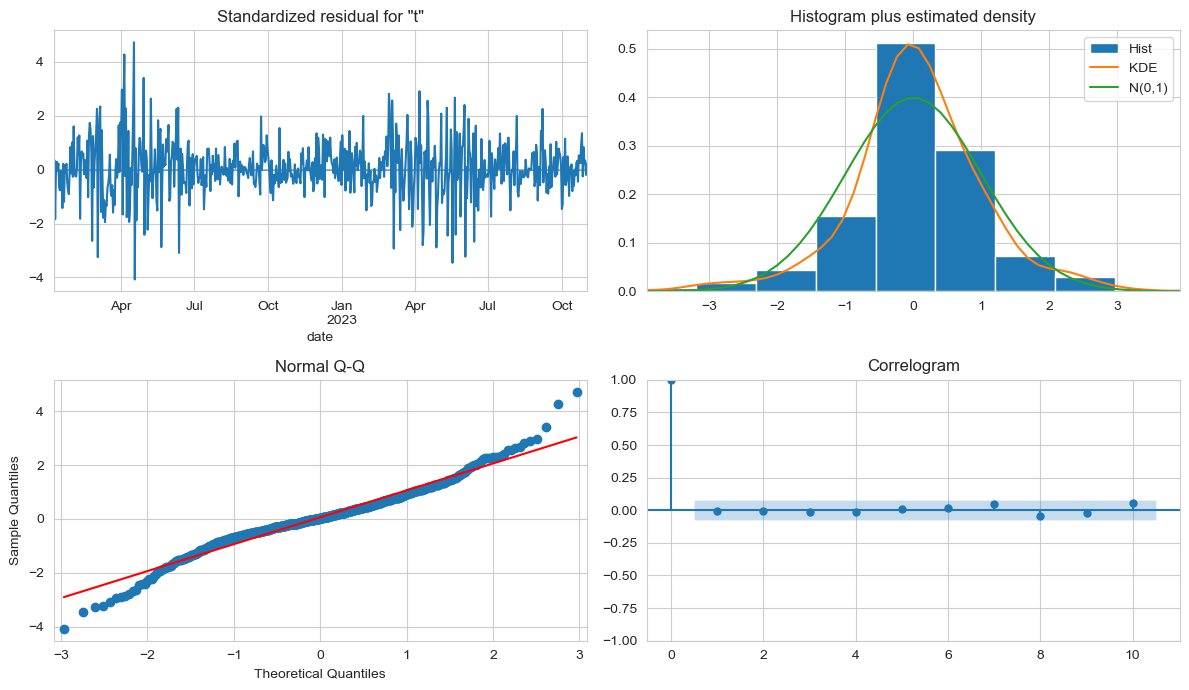


Ljung-Box test (p > 0.05 = white noise residuals):
      lb_stat  lb_pvalue
7   11.502302   0.118160
14  26.266098   0.023942


In [19]:
# residual diagnostics
sarimax_fit.plot_diagnostics(figsize=(12, 7))
plt.tight_layout()
plt.show()

# Ljung-Box test
lb = sm.stats.acorr_ljungbox(sarimax_fit.resid.dropna(), lags=[7, 14], return_df=True)
print("\nLjung-Box test (p > 0.05 = white noise residuals):")
print(lb)

SARIMAX  ->  MAE: 1.23, RMSE: 1.49, MAPE: 7.3%


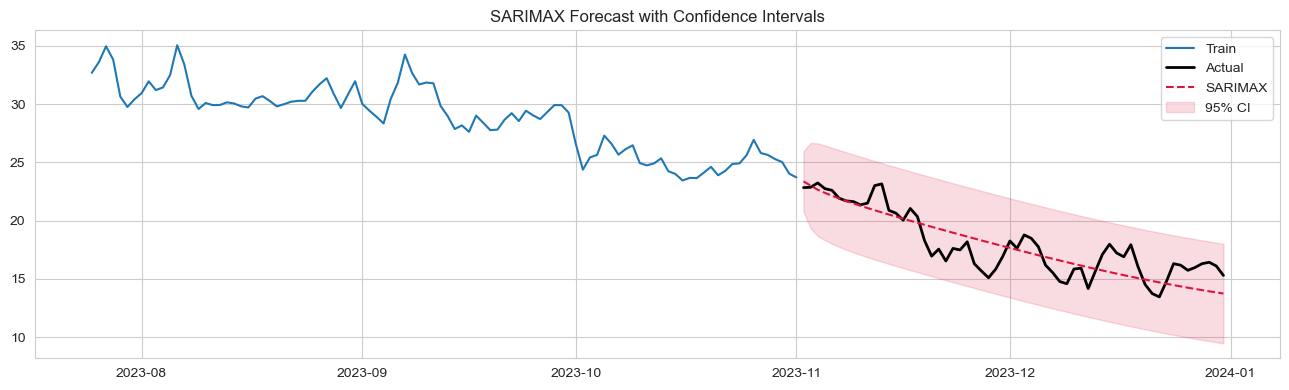

In [20]:
# forecast with confidence intervals
forecast_obj = sarimax_fit.get_forecast(steps=len(test), exog=fourier_test)
sarimax_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

mae = mean_absolute_error(test['temp_mean'], sarimax_pred)
rmse = np.sqrt(mean_squared_error(test['temp_mean'], sarimax_pred))
mape = np.mean(np.abs((test['temp_mean'] - sarimax_pred) / test['temp_mean'])) * 100

metrics['SARIMAX'] = {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,1)}
print(f"SARIMAX  ->  MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.1f}%")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index[-100:], train['temp_mean'].iloc[-100:], label='Train')
ax.plot(test.index, test['temp_mean'], label='Actual', color='black', lw=2)
ax.plot(test.index, sarimax_pred, label='SARIMAX', color='crimson', ls='--')
ax.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='crimson', alpha=0.15, label='95% CI')
ax.legend()
ax.set_title('SARIMAX Forecast with Confidence Intervals')
plt.tight_layout()
plt.show()

## 8. Walk-Forward Validation\nMore robust than a single split — refit the model on expanding windows.

In [21]:
tscv = TimeSeriesSplit(n_splits=5)
fold_maes = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(df)):
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]
    f_tr = make_fourier(tr.index)
    f_te = make_fourier(te.index)

    try:
        m = SARIMAX(tr['temp_mean'], exog=f_tr, order=sarimax_order,
                    enforce_stationarity=False, enforce_invertibility=False)
        f = m.fit(disp=False)
        pred = f.get_forecast(steps=len(te), exog=f_te).predicted_mean
        fold_maes.append(mean_absolute_error(te['temp_mean'], pred))
        print(f"Fold {fold+1}: MAE = {fold_maes[-1]:.2f}")
    except Exception as e:
        print(f"Fold {fold+1}: failed ({e})")

print(f"\nMean walk-forward MAE: {np.mean(fold_maes):.2f}")

Fold 1: MAE = 58.22


Fold 2: MAE = 1.58


Fold 3: MAE = 2.20


Fold 4: MAE = 1.34


Fold 5: MAE = 1.35

Mean walk-forward MAE: 12.94


## 9. Residual Analysis

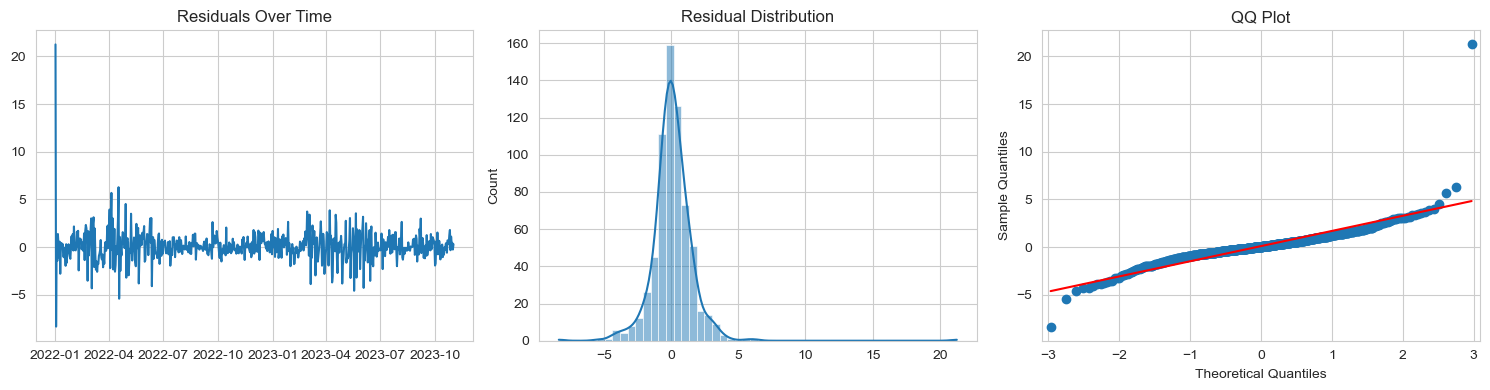

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sarimax_fit.resid)
axes[0].set_title('Residuals Over Time')

sns.histplot(sarimax_fit.resid, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')

sm.qqplot(sarimax_fit.resid, line='s', ax=axes[2])
axes[2].set_title('QQ Plot')

plt.tight_layout()
plt.show()

## 10. Bonus: RNN & LSTM\nSliding-window neural network approach for comparison.

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# scale on training data only
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['temp_mean']])
test_scaled = scaler.transform(test[['temp_mean']])

# sliding window helper
def make_windows(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 0])
        y.append(data[i+n_steps, 0])
    return np.array(X), np.array(y)

n_steps = 30  # lookback window

X_train, y_train = make_windows(train_scaled, n_steps)

# combine end of train with test so the first prediction uses only training data
combined = np.vstack([train_scaled[-n_steps:], test_scaled])
X_test, y_test = make_windows(combined, n_steps)

X_train = X_train.reshape(-1, n_steps, 1)
X_test = X_test.reshape(-1, n_steps, 1)

print(f"Train windows: {X_train.shape}, Test windows: {X_test.shape}")

Train windows: (640, 30, 1), Test windows: (60, 30, 1)


In [24]:
# Simple RNN baseline
tf.random.set_seed(42)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

rnn = Sequential([
    SimpleRNN(32, input_shape=(n_steps, 1)),
    Dense(1)
])
rnn.compile(optimizer='adam', loss='mse')
rnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=[es], verbose=0)

rnn_pred = scaler.inverse_transform(rnn.predict(X_test))
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_rnn = mean_absolute_error(y_true, rnn_pred)
rmse_rnn = np.sqrt(mean_squared_error(y_true, rnn_pred))
mape_rnn = np.mean(np.abs((y_true - rnn_pred) / y_true)) * 100
metrics['Simple RNN'] = {'MAE': round(mae_rnn,2), 'RMSE': round(rmse_rnn,2), 'MAPE': round(mape_rnn,1)}
print(f"Simple RNN  ->  MAE: {mae_rnn:.2f}, RMSE: {rmse_rnn:.2f}, MAPE: {mape_rnn:.1f}%")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


Simple RNN  ->  MAE: 0.84, RMSE: 1.00, MAPE: 4.8%


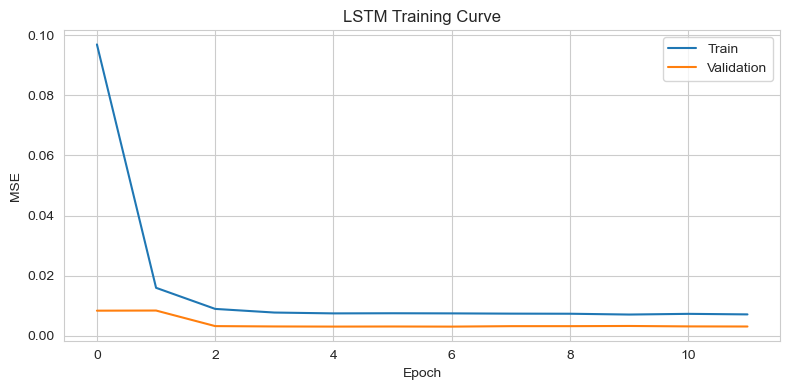

In [25]:
# LSTM
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_steps, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
history = lstm.fit(X_train, y_train, epochs=50, batch_size=32,
                   validation_split=0.1, callbacks=[es], verbose=0)

# training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'], label='Train')
ax.plot(history.history['val_loss'], label='Validation')
ax.set_title('LSTM Training Curve')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# evaluate LSTM
lstm_pred = scaler.inverse_transform(lstm.predict(X_test))

mae_lstm = mean_absolute_error(y_true, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_true, lstm_pred))
mape_lstm = np.mean(np.abs((y_true - lstm_pred) / y_true)) * 100
metrics['LSTM'] = {'MAE': round(mae_lstm,2), 'RMSE': round(rmse_lstm,2), 'MAPE': round(mape_lstm,1)}
print(f"LSTM  ->  MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.1f}%")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


LSTM  ->  MAE: 1.47, RMSE: 1.75, MAPE: 8.6%

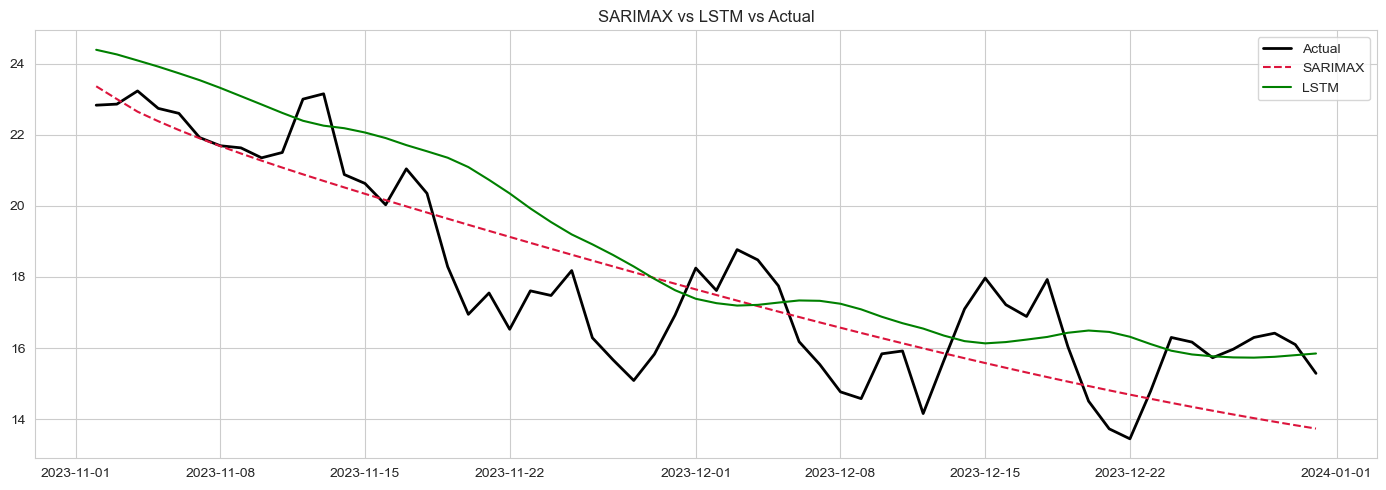

In [27]:
# all models vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test['temp_mean'], label='Actual', color='black', lw=2)
ax.plot(test.index, sarimax_pred.values, label='SARIMAX', color='crimson', ls='--')
ax.plot(test.index, lstm_pred.flatten(), label='LSTM', color='green')
ax.legend()
ax.set_title('SARIMAX vs LSTM vs Actual')
plt.tight_layout()
plt.show()

## 11. Model Comparison

             MAE  RMSE  MAPE
ARIMA       6.59  7.14  39.9
SARIMAX     1.23  1.49   7.3
Simple RNN  0.84  1.00   4.8
LSTM        1.47  1.75   8.6


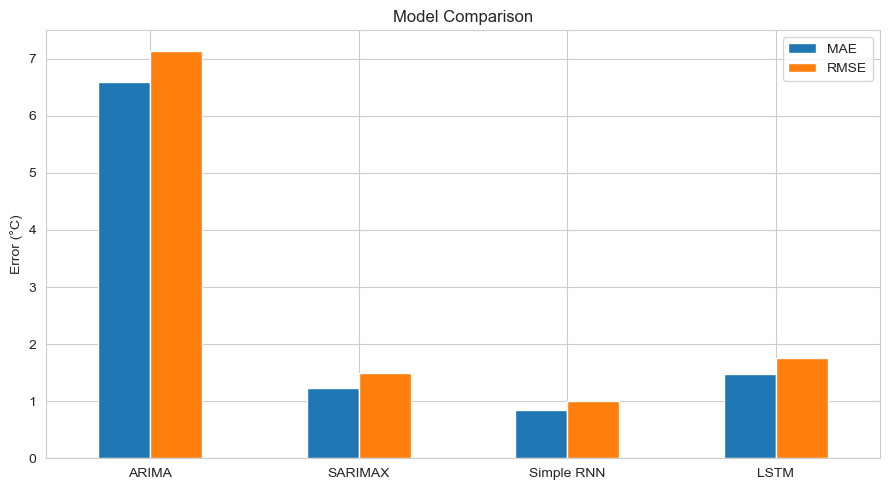

In [28]:
comparison = pd.DataFrame(metrics).T
print(comparison.to_string())

comparison[['MAE', 'RMSE']].plot(kind='bar', figsize=(9, 5), rot=0)
plt.title('Model Comparison')
plt.ylabel('Error (°C)')
plt.tight_layout()
plt.show()

## Conclusion

We compared ARIMA, SARIMAX (with Fourier terms), Simple RNN, and LSTM for forecasting Cairo\'s daily temperature over a 60-day test period.

**Findings:**
- Plain ARIMA reverts to the mean quickly and can\'t capture annual patterns
- SARIMAX with Fourier terms handles yearly seasonality properly since the sin/cos features encode where we are in the year
- LSTM learns temperature patterns from the sliding window of recent values
- Walk-forward validation gives a more reliable estimate than a single split

